# Measuring arc spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# For intrinsic broadening
# J0136 merged specs in 4826

wcal_red = fits.open('/home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')
wcal_blue = fits.open('/home/benjamin/Documents/pypeit19b/redux_J0136/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

----

# Two component model fit for [OIII] 4959

In [5]:
wcal_blue.info()

Filename: /home/benjamin/Documents/pypeit19b/redux_J0136/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (11,)   int64   
  2  SPAT_ID-323_WAVEFIT    1 BinTableHDU     40   1R x 6C   [43D, 43D, 43J, 2048D, 2048D, 45D]   
  3  SPAT_ID-323_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [43D, 43D, 1K, 43D, 5D, 43K]   
  4  SPAT_ID-408_WAVEFIT    1 BinTableHDU     40   1R x 6C   [41D, 41D, 41J, 2048D, 2048D, 46D]   
  5  SPAT_ID-408_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [41D, 41D, 1K, 41D, 5D, 41K]   
  6  SPAT_ID-485_WAVEFIT    1 BinTableHDU     40   1R x 6C   [49D, 49D, 49J, 2048D, 2048D, 50D]   
  7  SPAT_ID-485_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [49D, 49D, 1K, 49D, 5D, 49K]   
  8  SPAT_ID-557_WAVEFIT    1 BinTableHDU     40   1R x 6C   [60D, 60D, 60J, 2048D, 2048D, 60D]   
  9  SPAT_ID-557_PYPEITFIT    1

In [6]:
wcal_red.info()

Filename: /home/benjamin/Documents/pypeit19b/redux_J0136/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (8,)   int64   
  2  SPAT_ID-623_WAVEFIT    1 BinTableHDU     40   1R x 6C   [50D, 50D, 50J, 2048D, 2048D, 51D]   
  3  SPAT_ID-623_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [50D, 50D, 1K, 50D, 5D, 50K]   
  4  SPAT_ID-684_WAVEFIT    1 BinTableHDU     40   1R x 6C   [50D, 50D, 50J, 2048D, 2048D, 52D]   
  5  SPAT_ID-684_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [50D, 50D, 1K, 50D, 5D, 50K]   
  6  SPAT_ID-740_WAVEFIT    1 BinTableHDU     40   1R x 6C   [62D, 62D, 62J, 2048D, 2048D, 65D]   
  7  SPAT_ID-740_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [62D, 62D, 1K, 62D, 5D, 62K]   
  8  SPAT_ID-793_WAVEFIT    1 BinTableHDU     40   1R x 6C   [69D, 69D, 69J, 2048D, 2048D, 71D]   
  9  SPAT_ID-793_PYPEITFIT    1 B

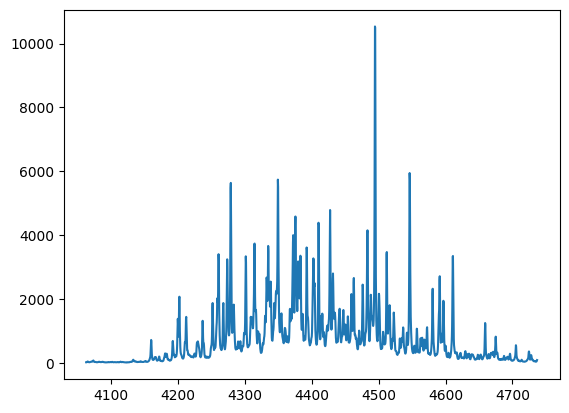

In [7]:
plt.plot(wcal_blue[8].data['wave_soln'][0], wcal_blue[25].data[:, 3])

# [OIII]4959

### Arc lines

In [8]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4959 = [wave_cat['[OIII]4959']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4959']*(1 + z_BN[igal]) + 10]
mask_arc_4959 = (wcal_red[4].data['wave_soln'][0] >= wlims_4959[0]) & (wcal_red[4].data['wave_soln'][0] < wlims_4959[1])

# Arc spectra around the fitted line
x_arc_4959 = wcal_red[4].data['wave_soln'][0][mask_arc_4959]
y_arc_4959 = wcal_red[19].data[:, 1][mask_arc_4959]

100%|██████████████████████████████████████| 2500/2500 [00:15<00:00, 165.40it/s]


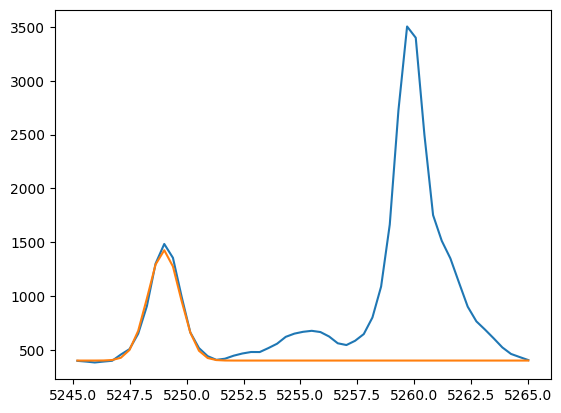

In [9]:
plt.plot(x_arc_4959, y_arc_4959)
plt.plot(x_arc_4959, 400 + gaussian(x_arc_4959, 1800, 5249, 0, 0.7))

params_arc_4959 = Parameters()
params_arc_4959.add('z', value=0.0, vary=False)
params_arc_4959.add('mu', value=5249, vary=False)
params_arc_4959.add('arc', value=1800, min=0.)
params_arc_4959.add('sigma', value=0.7, min=0.)
params_arc_4959.add('bkg', value=400, vary=False)

def residual_arc_4959(params_arc_4959, x, data, uncertainty):
    
    z = params_arc_4959['z']
    mu = params_arc_4959['mu']
    flux = params_arc_4959['arc']
    sigma = params_arc_4959['sigma']
    bkg = params_arc_4959['bkg']
    
    x = x_arc_4959
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_4959) / 10

np.random.seed(136)
out_arc_4959 = minimize(residual_arc_4959, params_arc_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

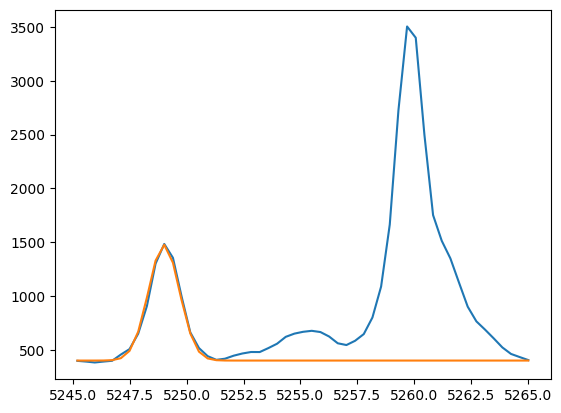

In [10]:
arc_4959 = out_arc_4959.flatchain.arc.mean()
sigma_arc_4959 = out_arc_4959.flatchain.sigma.mean()

plt.plot(x_arc_4959, y_arc_4959)

plt.plot(x_arc_4959, 400 + gaussian(x_arc_4959, arc_4959, 5249, 0, sigma_arc_4959))

---

# HeII 4686

### Arc lines

In [21]:
wave_cat['HeII4685']*(1 + z_BN[igal])

4965.6343154

In [22]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4685 = [wave_cat['HeII4685']*(1 + z_BN[igal]) - 2, wave_cat['HeII4685']*(1 + z_BN[igal]) + 10]
mask_arc_4685 = (wcal_red[2].data['wave_soln'][0] >= wlims_4685[0]) & (wcal_red[2].data['wave_soln'][0] < wlims_4685[1])

# Arc spectra around the fitted line
x_arc_4685 = wcal_red[2].data['wave_soln'][0][mask_arc_4685]
y_arc_4685 = wcal_red[19].data[:, 0][mask_arc_4685]

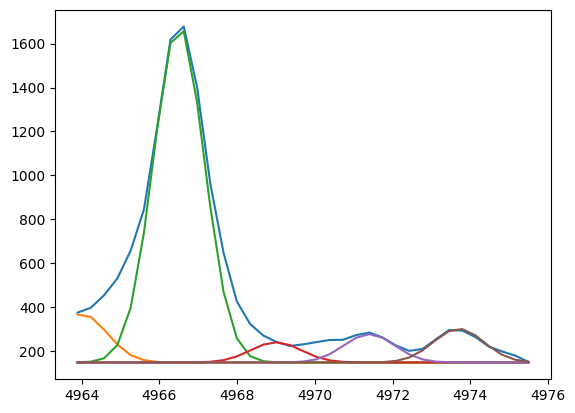

In [23]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 360, 4964, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 2500, 4966.5, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 150, 4969, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 210, 4971.4, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 250, 4973.7, 0, 0.65))

100%|███████████████████████████████████████| 2500/2500 [00:28<00:00, 86.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [112.7854229   38.60866859  64.04245061  76.87248468  47.83988025
  42.22939221]


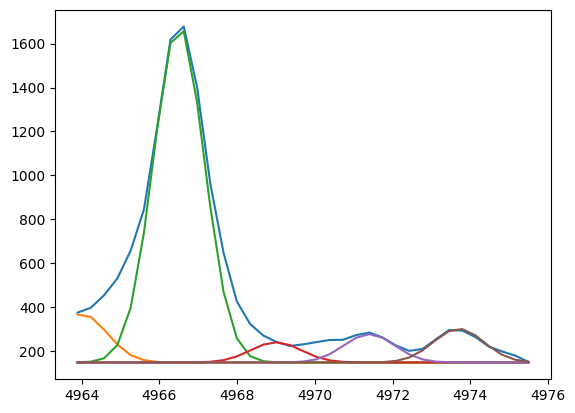

In [24]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 360, 4964, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 2500, 4966.5, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 150, 4969, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 210, 4971.4, 0, 0.65))
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, 250, 4973.7, 0, 0.65))

params_arc_4685 = Parameters()
params_arc_4685.add('z', value=0.0, vary=False)
params_arc_4685.add('mu1', value=4964, vary=False)
params_arc_4685.add('mu2', value=4966.5, vary=False)
params_arc_4685.add('mu3', value=4969, vary=False)
params_arc_4685.add('mu4', value=4971.4, vary=False)
params_arc_4685.add('mu5', value=4973.7, vary=False)
params_arc_4685.add('arc1', value=360, min=0.)
params_arc_4685.add('arc2', value=2500, min=0.)
params_arc_4685.add('arc3', value=150, min=0.)
params_arc_4685.add('arc4', value=210, min=0.)
params_arc_4685.add('arc5', value=250, min=0.)
params_arc_4685.add('sigma', value=0.65, min=0.)
params_arc_4685.add('bkg', value=150, vary=False)

def residual_arc_4685(params_arc_4685, x, data, uncertainty):
    
    z = params_arc_4685['z']
    mu1 = params_arc_4685['mu1']
    mu2 = params_arc_4685['mu2']
    mu3 = params_arc_4685['mu3']
    mu4 = params_arc_4685['mu4']
    mu5 = params_arc_4685['mu5']
    flux1 = params_arc_4685['arc1']
    flux2 = params_arc_4685['arc2']
    flux3 = params_arc_4685['arc3']
    flux4 = params_arc_4685['arc4']
    flux5 = params_arc_4685['arc5']
    sigma = params_arc_4685['sigma']
    bkg = params_arc_4685['bkg']
    
    x = x_arc_4685
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_4685) / 10

np.random.seed(136)
out_arc_4685 = minimize(residual_arc_4685, params_arc_4685, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [25]:
out_arc_4685.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4964.00000,,,4964,-inf,inf,False
mu2,4966.50000,,,4966.5,-inf,inf,False
mu3,4969.00000,,,4969,-inf,inf,False
mu4,4971.40000,,,4971.4,-inf,inf,False
mu5,4973.70000,,,4973.7,-inf,inf,False
arc1,515.986729,11.9320832,(2.31%),360,0.00000000,inf,True
arc2,2844.12115,11.3371477,(0.40%),2500,0.00000000,inf,True
arc3,199.523077,9.80806755,(4.92%),150,0.00000000,inf,True
arc4,241.233683,9.75535644,(4.04%),210,0.00000000,inf,True


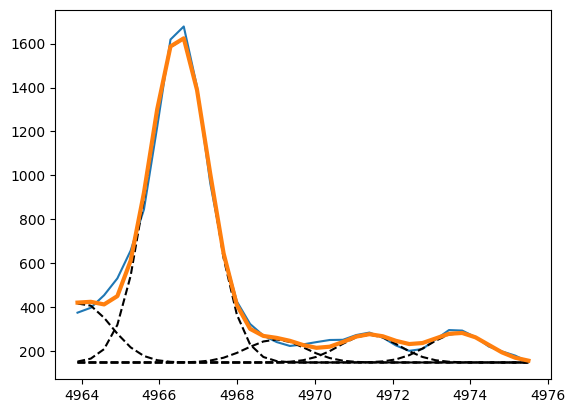

In [26]:
arc1_4685 = out_arc_4685.flatchain.arc1.mean()
arc2_4685 = out_arc_4685.flatchain.arc2.mean()
arc3_4685 = out_arc_4685.flatchain.arc3.mean()
arc4_4685 = out_arc_4685.flatchain.arc4.mean()
arc5_4685 = out_arc_4685.flatchain.arc5.mean()
sigma_arc_4685 = out_arc_4685.flatchain.sigma.mean()

plt.plot(x_arc_4685, y_arc_4685)

plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc1_4685, 4964, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc2_4685, 4966.5, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc3_4685, 4969, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc4_4685, 4971.4, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc5_4685, 4973.7, 0, sigma_arc_4685), ls='--', color='black')

plt.plot(x_arc_4685, 150 + gaussian(x_arc_4685, arc1_4685, 4964, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc2_4685, 4966.5, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc3_4685, 4969, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc4_4685, 4971.4, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc5_4685, 4973.7, 0, sigma_arc_4685), lw=3
)

# [NII]6548 + H$\alpha$ + [NII]6584

### Arc lines

In [36]:
wave_cat['Ha']*(1 + z_BN[igal])

6954.851074599999

In [37]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_ha = [wave_cat['Ha']*(1 + z_BN[igal]) - 30, wave_cat['Ha']*(1 + z_BN[igal]) + 3]
mask_arc_ha = (wcal_red[10].data['wave_soln'][0] >= wlims_ha[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_ha[1])

# Arc spectra around the fitted line
x_arc_ha = wcal_red[10].data['wave_soln'][0][mask_arc_ha]
y_arc_ha = wcal_red[19].data[:, 4][mask_arc_ha]

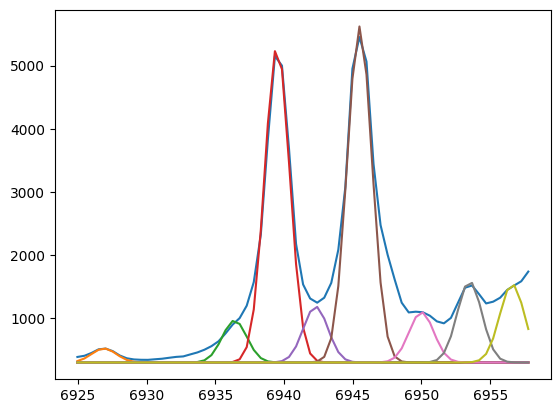

In [38]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 500, 6926.9, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 1500, 6936.4, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 11300, 6939.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2000, 6942.3, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 12000, 6945.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 1800, 6950, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2900, 6953.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2800, 6956.6, 0, 0.9))

100%|███████████████████████████████████████| 2500/2500 [00:46<00:00, 53.53it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [216.09238906 181.10878     32.00047004  43.19631334  62.53076474
  26.55785871  29.37829922 117.07276085  88.36861182]


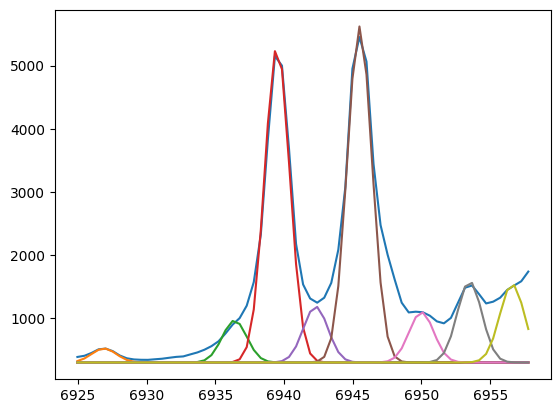

In [39]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 500, 6926.9, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 1500, 6936.4, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 11300, 6939.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2000, 6942.3, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 12000, 6945.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 1800, 6950, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2900, 6953.5, 0, 0.9))
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, 2800, 6956.6, 0, 0.9))

params_arc_ha = Parameters()
params_arc_ha.add('z', value=0.0, vary=False)
params_arc_ha.add('mu1', value=6926.9, vary=False)
params_arc_ha.add('mu2', value=6936.4, vary=False)
params_arc_ha.add('mu3', value=6939.5, vary=False)
params_arc_ha.add('mu4', value=6942.3, vary=False)
params_arc_ha.add('mu5', value=6945.5, vary=False)
params_arc_ha.add('mu6', value=6950, vary=False)
params_arc_ha.add('mu7', value=6953.5, vary=False)
params_arc_ha.add('mu8', value=6956.6, vary=False)
params_arc_ha.add('arc1', value=500, min=0.)
params_arc_ha.add('arc2', value=1500, min=0.)
params_arc_ha.add('arc3', value=11300, min=0.)
params_arc_ha.add('arc4', value=2000, min=0.)
params_arc_ha.add('arc5', value=12000, min=0.)
params_arc_ha.add('arc6', value=1800, min=0.)
params_arc_ha.add('arc7', value=2900, min=0.)
params_arc_ha.add('arc8', value=2800, min=0.)
params_arc_ha.add('sigma', value=0.6, min=0.)
params_arc_ha.add('bkg', value=300, vary=False)

def residual_arc_ha(params_arc_ha, x, data, uncertainty):
    
    z = params_arc_ha['z']
    mu1 = params_arc_ha['mu1']
    mu2 = params_arc_ha['mu2']
    mu3 = params_arc_ha['mu3']
    mu4 = params_arc_ha['mu4']
    mu5 = params_arc_ha['mu5']
    mu6 = params_arc_ha['mu6']
    mu7 = params_arc_ha['mu7']
    mu8 = params_arc_ha['mu8']
    flux1 = params_arc_ha['arc1']
    flux2 = params_arc_ha['arc2']
    flux3 = params_arc_ha['arc3']
    flux4 = params_arc_ha['arc4']
    flux5 = params_arc_ha['arc5']
    flux6 = params_arc_ha['arc6']
    flux7 = params_arc_ha['arc7']
    flux8 = params_arc_ha['arc8']
    sigma = params_arc_ha['sigma']
    bkg = params_arc_ha['bkg']
    
    x = x_arc_ha
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model8 = gaussian(x, flux8, mu8, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7 + model8
    return (model - y_arc_ha) / 10

np.random.seed(136)
out_arc_ha = minimize(residual_arc_ha, params_arc_ha, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [40]:
out_arc_ha.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6926.90000,,,6926.9,-inf,inf,False
mu2,6936.40000,,,6936.4,-inf,inf,False
mu3,6939.50000,,,6939.5,-inf,inf,False
mu4,6942.30000,,,6942.3,-inf,inf,False
mu5,6945.50000,,,6945.5,-inf,inf,False
mu6,6950.00000,,,6950,-inf,inf,False
mu7,6953.50000,,,6953.5,-inf,inf,False
mu8,6956.60000,,,6956.6,-inf,inf,False
arc1,602.744327,13.8940404,(2.31%),500,0.00000000,inf,True


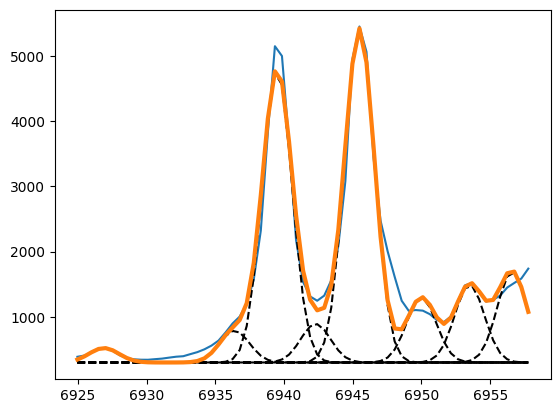

In [41]:
arc1_ha = out_arc_ha.flatchain.arc1.mean()
arc2_ha = out_arc_ha.flatchain.arc2.mean()
arc3_ha = out_arc_ha.flatchain.arc3.mean()
arc4_ha = out_arc_ha.flatchain.arc4.mean()
arc5_ha = out_arc_ha.flatchain.arc5.mean()
arc6_ha = out_arc_ha.flatchain.arc6.mean()
arc7_ha = out_arc_ha.flatchain.arc7.mean()
arc8_ha = out_arc_ha.flatchain.arc8.mean()
sigma_arc_ha = out_arc_ha.flatchain.sigma.mean()

plt.plot(x_arc_ha, y_arc_ha)

plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc1_ha, 6926.9, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc2_ha, 6936.4, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc3_ha, 6939.5, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc4_ha, 6942.3, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc5_ha, 6945.5, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc6_ha,   6950, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc7_ha, 6953.5, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc8_ha, 6956.6, 0, sigma_arc_ha), ls='--', color='black')

plt.plot(x_arc_ha, 300 + gaussian(x_arc_ha, arc1_ha, 6926.9, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc2_ha, 6936.4, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc3_ha, 6939.5, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc4_ha, 6942.3, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc5_ha, 6945.5, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc6_ha,   6950, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc7_ha, 6953.5, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc8_ha, 6956.6, 0, sigma_arc_ha), lw=3
)

# [OII]7319 + [OII]7330

### Arc lines

In [50]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7330 = [wave_cat['[OII]7330']*(1 + z_BN[igal]) - 10, wave_cat['[OII]7330']*(1 + z_BN[igal]) + 30]
mask_arc_7330 = (wcal_red[12].data['wave_soln'][0] >= wlims_7330[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_7330[1])

# Arc spectra around the fitted line
x_arc_7330 = wcal_red[12].data['wave_soln'][0][mask_arc_7330]
y_arc_7330 = wcal_red[19].data[:, 5][mask_arc_7330]

100%|███████████████████████████████████████| 2500/2500 [00:49<00:00, 50.95it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [49.30060519 47.43928239 55.25148294 48.55598858 49.38616813]


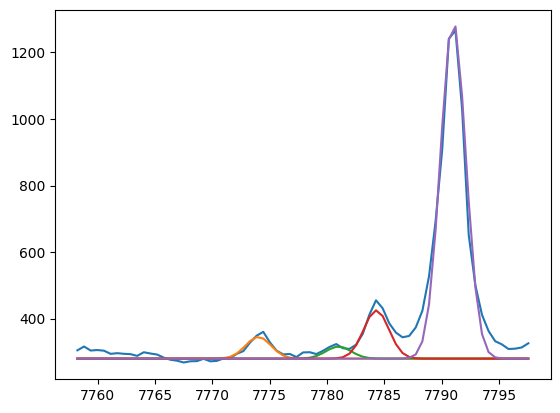

In [51]:
plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, 180, 7774, 0, 1.1))
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, 100, 7781, 0, 1.1))
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, 400, 7784.3, 0, 1.1))
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, 2800, 7791, 0, 1.1))

params_arc_7330 = Parameters()
params_arc_7330.add('z', value=0.0, vary=False)
params_arc_7330.add('mu1', value=7774, vary=False)
params_arc_7330.add('mu2', value=7781, vary=False)
params_arc_7330.add('mu3', value=7784.3, vary=False)
params_arc_7330.add('mu4', value=7791, vary=False)
params_arc_7330.add('arc1', value=180, min=0.)
params_arc_7330.add('arc2', value=100, min=0.)
params_arc_7330.add('arc3', value=400, min=0.)
params_arc_7330.add('arc4', value=2800, min=0.)
params_arc_7330.add('sigma', value=1.1, min=0.)
params_arc_7330.add('bkg', value=280, vary=False)

def residual_arc_7330(params_arc_7330, x, data, uncertainty):
    
    z = params_arc_7330['z']
    mu1 = params_arc_7330['mu1']
    mu2 = params_arc_7330['mu2']
    mu3 = params_arc_7330['mu3']
    mu4 = params_arc_7330['mu4']
    flux1 = params_arc_7330['arc1']
    flux2 = params_arc_7330['arc2']
    flux3 = params_arc_7330['arc3']
    flux4 = params_arc_7330['arc4']
    sigma = params_arc_7330['sigma']
    bkg = params_arc_7330['bkg']
    
    x = x_arc_7330
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_7330) / 10

np.random.seed(136)
out_arc_7330 = minimize(residual_arc_7330, params_arc_7330, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

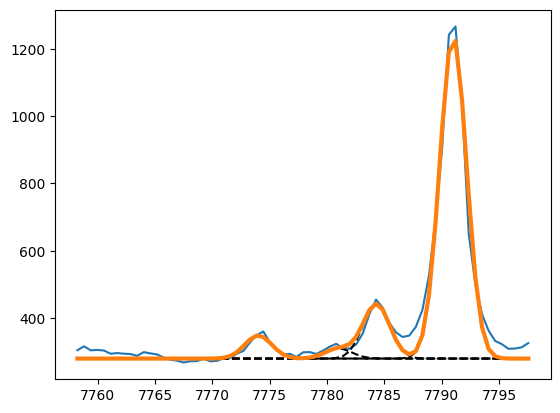

In [52]:
arc1_7330 = out_arc_7330.flatchain.arc1.mean()
arc2_7330 = out_arc_7330.flatchain.arc2.mean()
arc3_7330 = out_arc_7330.flatchain.arc3.mean()
arc4_7330 = out_arc_7330.flatchain.arc4.mean()
sigma_arc_7330 = out_arc_7330.flatchain.sigma.mean()

plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, arc1_7330, 7774, 0, sigma_arc_7330), color='black', ls='--')
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, arc2_7330, 7781, 0, sigma_arc_7330), color='black', ls='--')
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, arc3_7330, 7784.3, 0, sigma_arc_7330), color='black', ls='--')
plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, arc4_7330, 7791, 0, sigma_arc_7330), color='black', ls='--')

plt.plot(x_arc_7330, 280 + gaussian(x_arc_7330, arc1_7330, 7774, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc2_7330, 7781, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc3_7330, 7784.3, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc4_7330, 7791, 0, sigma_arc_7330), lw=3
)

# [SII]6716 + [SII]6730

### Arc lines

In [61]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6730 = [wave_cat['[SII]6730']*(1 + z_BN[igal]) - 10, wave_cat['[SII]6730']*(1 + z_BN[igal]) + 5]
mask_arc_6730 = (wcal_red[10].data['wave_soln'][0] >= wlims_6730[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_6730[1])

# Arc spectra around the fitted line
x_arc_6730 = wcal_red[10].data['wave_soln'][0][mask_arc_6730]
y_arc_6730 = wcal_red[19].data[:, 4][mask_arc_6730]

100%|███████████████████████████████████████| 2500/2500 [01:04<00:00, 38.87it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [113.48868939  52.77939998  67.30859796  55.1447072   55.36055828
  24.70065208]


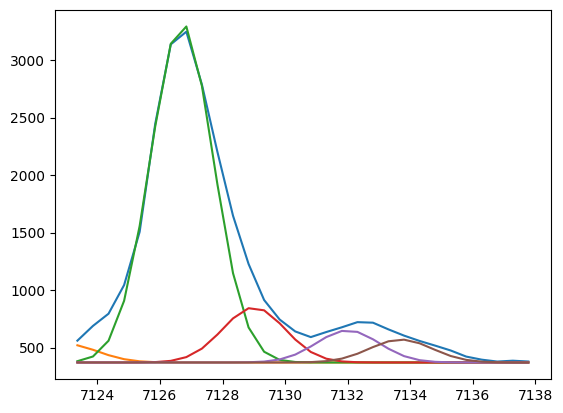

In [62]:
plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730,  400, 7123, 0, 1.0))
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, 7400, 7126.7, 0, 1.0))
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, 1200, 7129, 0, 1.0))
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730,  700, 7132, 0, 1.0))
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730,  500, 7133.7, 0, 1.0))

params_arc_6730 = Parameters()
params_arc_6730.add('z', value=0.0, vary=False)
params_arc_6730.add('mu1', value=7123, vary=False)
params_arc_6730.add('mu2', value=7126.7, vary=False)
params_arc_6730.add('mu3', value=7129, vary=False)
params_arc_6730.add('mu4', value=7132, vary=False)
params_arc_6730.add('mu5', value=7133.7, vary=False)
params_arc_6730.add('arc1', value=400, min=0.)
params_arc_6730.add('arc2', value=7400, min=0.)
params_arc_6730.add('arc3', value=1200, min=0.)
params_arc_6730.add('arc4', value=700, min=0.)
params_arc_6730.add('arc5', value=500, min=0.)
params_arc_6730.add('sigma', value=1.0, min=0.)
params_arc_6730.add('bkg', value=370, vary=False)

def residual_arc_6730(params_arc_6730, x, data, uncertainty):
    
    z = params_arc_6730['z']
    mu1 = params_arc_6730['mu1']
    mu2 = params_arc_6730['mu2']
    mu3 = params_arc_6730['mu3']
    mu4 = params_arc_6730['mu4']
    mu5 = params_arc_6730['mu5']
    flux1 = params_arc_6730['arc1']
    flux2 = params_arc_6730['arc2']
    flux3 = params_arc_6730['arc3']
    flux4 = params_arc_6730['arc4']
    flux5 = params_arc_6730['arc5']
    sigma = params_arc_6730['sigma']
    bkg = params_arc_6730['bkg']
    
    x = x_arc_6730
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_6730) / 10

np.random.seed(136)
out_arc_6730 = minimize(residual_arc_6730, params_arc_6730, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

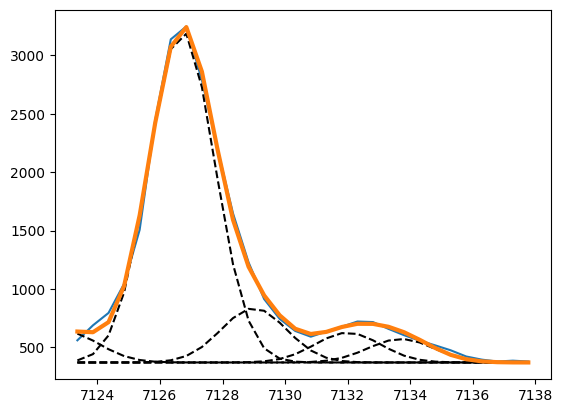

In [63]:
arc1_6730 = out_arc_6730.flatchain.arc1.mean()
arc2_6730 = out_arc_6730.flatchain.arc2.mean()
arc3_6730 = out_arc_6730.flatchain.arc3.mean()
arc4_6730 = out_arc_6730.flatchain.arc4.mean()
arc5_6730 = out_arc_6730.flatchain.arc5.mean()
sigma_arc_6730 = out_arc_6730.flatchain.sigma.mean()

plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc1_6730, 7123, 0, sigma_arc_6730), color='black', ls='--')
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc2_6730, 7126.7, 0, sigma_arc_6730), color='black', ls='--')
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc3_6730, 7129, 0, sigma_arc_6730), color='black', ls='--')
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc4_6730, 7132, 0, sigma_arc_6730), color='black', ls='--')
plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc5_6730, 7133.7, 0, sigma_arc_6730), color='black', ls='--')

plt.plot(x_arc_6730, 370 + gaussian(x_arc_6730, arc1_6730, 7123, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc2_6730, 7126.7, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc3_6730, 7129, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc4_6730, 7132, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc5_6730, 7133.7, 0, sigma_arc_6730), lw=3
)

# H$\beta$

### Arc lines

In [72]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hb = [wave_cat['Hb']*(1 + z_BN[igal]) - 10, wave_cat['Hb']*(1 + z_BN[igal]) + 10]
mask_arc_hb = (wcal_red[4].data['wave_soln'][0] >= wlims_hb[0]) & (wcal_red[4].data['wave_soln'][0] < wlims_hb[1])

# Arc spectra around the fitted line
x_arc_hb = wcal_red[4].data['wave_soln'][0][mask_arc_hb]
y_arc_hb = wcal_red[19].data[:, 1][mask_arc_hb]

100%|███████████████████████████████████████| 2500/2500 [01:42<00:00, 24.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [55.09270481 48.7506004  65.75451941 46.72244857 41.84227928 71.00305421
 58.59895314]


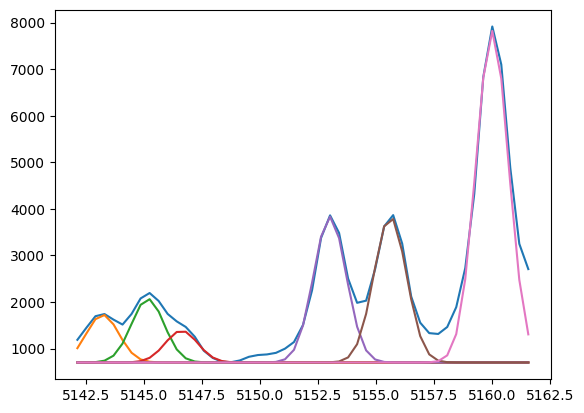

In [73]:
plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 1800, 5143.2, 0, 0.7))
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 2400, 5145.15, 0, 0.7))
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 1200, 5146.6, 0, 0.7))
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 5500, 5153, 0, 0.7))
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 5500, 5155.6, 0, 0.7))
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, 12500, 5160, 0, 0.7))

params_arc_hb = Parameters()
params_arc_hb.add('z', value=0.0, vary=False)
params_arc_hb.add('mu1', value=5143.2, vary=False)
params_arc_hb.add('mu2', value=5145.15, vary=False)
params_arc_hb.add('mu3', value=5146.6, vary=False)
params_arc_hb.add('mu4', value=5153, vary=False)
params_arc_hb.add('mu5', value=5155.6, vary=False)
params_arc_hb.add('mu6', value=5160, vary=False)
params_arc_hb.add('arc1', value=1800, min=0.)
params_arc_hb.add('arc2', value=2400, min=0.)
params_arc_hb.add('arc3', value=1200, min=0.)
params_arc_hb.add('arc4', value=5500, min=0.)
params_arc_hb.add('arc5', value=5500, min=0.)
params_arc_hb.add('arc6', value=12500, min=0.)
params_arc_hb.add('sigma', value=0.7, min=0.)
params_arc_hb.add('bkg', value=700, vary=False)

def residual_arc_hb(params_arc_hb, x, data, uncertainty):
    
    z = params_arc_hb['z']
    mu1 = params_arc_hb['mu1']
    mu2 = params_arc_hb['mu2']
    mu3 = params_arc_hb['mu3']
    mu4 = params_arc_hb['mu4']
    mu5 = params_arc_hb['mu5']
    mu6 = params_arc_hb['mu6']
    flux1 = params_arc_hb['arc1']
    flux2 = params_arc_hb['arc2']
    flux3 = params_arc_hb['arc3']
    flux4 = params_arc_hb['arc4']
    flux5 = params_arc_hb['arc5']
    flux6 = params_arc_hb['arc6']
    sigma = params_arc_hb['sigma']
    bkg = params_arc_hb['bkg']
    
    x = x_arc_hb
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6
    return (model - y_arc_hb) / 10

np.random.seed(136)
out_arc_hb = minimize(residual_arc_hb, params_arc_hb, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

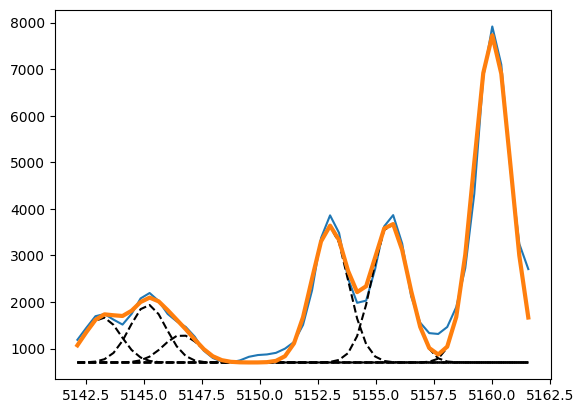

In [74]:
arc1_hb = out_arc_hb.flatchain.arc1.mean()
arc2_hb = out_arc_hb.flatchain.arc2.mean()
arc3_hb = out_arc_hb.flatchain.arc3.mean()
arc4_hb = out_arc_hb.flatchain.arc4.mean()
arc5_hb = out_arc_hb.flatchain.arc5.mean()
arc6_hb = out_arc_hb.flatchain.arc6.mean()
sigma_arc_hb = out_arc_hb.flatchain.sigma.mean()

plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc1_hb,  5143.2, 0, sigma_arc_hb), color='black', ls='--')
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc2_hb, 5145.15, 0, sigma_arc_hb), color='black', ls='--')
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc3_hb,  5146.6, 0, sigma_arc_hb), color='black', ls='--')
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc4_hb,    5153, 0, sigma_arc_hb), color='black', ls='--')
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc5_hb,  5155.6, 0, sigma_arc_hb), color='black', ls='--')
plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc6_hb,    5160, 0, sigma_arc_hb), color='black', ls='--')

plt.plot(x_arc_hb, 700 + gaussian(x_arc_hb, arc1_hb,  5143.2, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc2_hb, 5145.15, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc3_hb,  5146.6, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc4_hb,    5153, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc5_hb,  5155.6, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc6_hb,    5160, 0, sigma_arc_hb), lw=3
)

# H$\gamma$

### Arc lines

In [83]:
wave_cat['Hg']*(1 + z_BN[igal])

4599.771797279999

In [84]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hg = [wave_cat['Hg']*(1 + z_BN[igal]) - 10, wave_cat['Hg']*(1 + z_BN[igal]) + 8]
mask_arc_hg = (wcal_blue[8].data['wave_soln'][0] >= wlims_hg[0]) & (wcal_blue[8].data['wave_soln'][0] < wlims_hg[1])

# Arc spectra around the fitted line
x_arc_hg = wcal_blue[8].data['wave_soln'][0][mask_arc_hg]
y_arc_hg = wcal_blue[25].data[:, 3][mask_arc_hg]

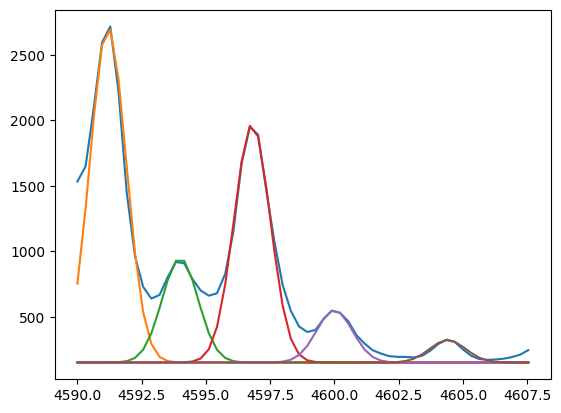

In [85]:
plt.plot(x_arc_hg, y_arc_hg)
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, 4500, 4591.2, 0, 0.7))
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, 1400,   4594, 0, 0.7))
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, 3200, 4596.8, 0, 0.7))
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg,  700,   4600, 0, 0.7))
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg,  300, 4604.4, 0, 0.7))

In [86]:
params_arc_hg = Parameters()
params_arc_hg.add('z', value=0.0, vary=False)
params_arc_hg.add('mu1', value=4591.2, vary=False)
params_arc_hg.add('mu2', value=  4594, vary=False)
params_arc_hg.add('mu3', value=4596.8, vary=False)
params_arc_hg.add('mu4', value=  4600, vary=False)
params_arc_hg.add('mu5', value=4604.4, vary=False)
params_arc_hg.add('arc1', value=4500, min=0.)
params_arc_hg.add('arc2', value=1400, min=0.)
params_arc_hg.add('arc3', value=3200, min=0.)
params_arc_hg.add('arc4', value= 700, min=0.)
params_arc_hg.add('arc5', value= 300, min=0.)
params_arc_hg.add('sigma', value=0.7, min=0.)
params_arc_hg.add('bkg', value=150, vary=False)

def residual_arc_hg(params_arc_hg, x, data, uncertainty):
    
    z = params_arc_hg['z']
    mu1 = params_arc_hg['mu1']
    mu2 = params_arc_hg['mu2']
    mu3 = params_arc_hg['mu3']
    mu4 = params_arc_hg['mu4']
    mu5 = params_arc_hg['mu5']
    flux1 = params_arc_hg['arc1']
    flux2 = params_arc_hg['arc2']
    flux3 = params_arc_hg['arc3']
    flux4 = params_arc_hg['arc4']
    flux5 = params_arc_hg['arc5']
    sigma = params_arc_hg['sigma']
    bkg = params_arc_hg['bkg']
    
    x = x_arc_hg
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_hg) / 10

np.random.seed(136)
out_arc_hg = minimize(residual_arc_hg, params_arc_hg, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:46<00:00, 23.56it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 75.61211822  32.13221567  84.63191938 101.85146489  50.76729569
  79.41238068]


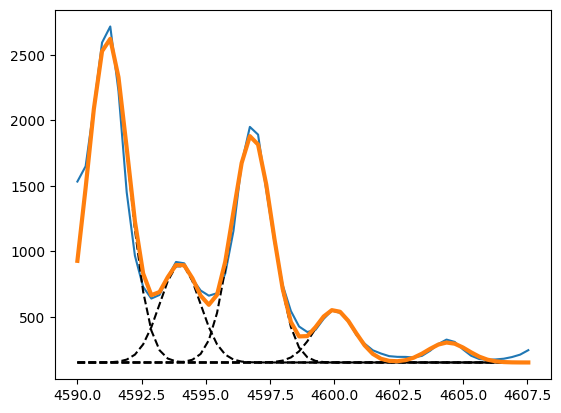

In [87]:
arc1_hg = out_arc_hg.flatchain.arc1.mean()
arc2_hg = out_arc_hg.flatchain.arc2.mean()
arc3_hg = out_arc_hg.flatchain.arc3.mean()
arc4_hg = out_arc_hg.flatchain.arc4.mean()
arc5_hg = out_arc_hg.flatchain.arc5.mean()
sigma_arc_hg = out_arc_hg.flatchain.sigma.mean()

plt.plot(x_arc_hg, y_arc_hg)
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc1_hg, 4591.2, 0, sigma_arc_hg), color='black', ls='--')
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc2_hg,   4594, 0, sigma_arc_hg), color='black', ls='--')
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc3_hg, 4596.8, 0, sigma_arc_hg), color='black', ls='--')
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc4_hg,   4600, 0, sigma_arc_hg), color='black', ls='--')
plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc5_hg, 4604.4, 0, sigma_arc_hg), color='black', ls='--')

plt.plot(x_arc_hg, 150 + gaussian(x_arc_hg, arc1_hg, 4591.2, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc2_hg,   4594, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc3_hg, 4596.8, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc4_hg,   4600, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc5_hg, 4604.4, 0, sigma_arc_hg), lw=3
)

# H$\delta$

### Arc lines

In [96]:
wave_cat['Hd'] * (1 + z_BN[igal])

4346.74644894798

In [97]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hd = [wave_cat['Hd']*(1 + z_BN[igal]), wave_cat['Hd']*(1 + z_BN[igal]) + 5]
mask_arc_hd = (wcal_blue[8].data['wave_soln'][0] >= wlims_hd[0]) & (wcal_blue[8].data['wave_soln'][0] < wlims_hd[1])

# Arc spectra around the fitted line
x_arc_hd = wcal_blue[8].data['wave_soln'][0][mask_arc_hd]
y_arc_hd = wcal_blue[25].data[:, 3][mask_arc_hd]

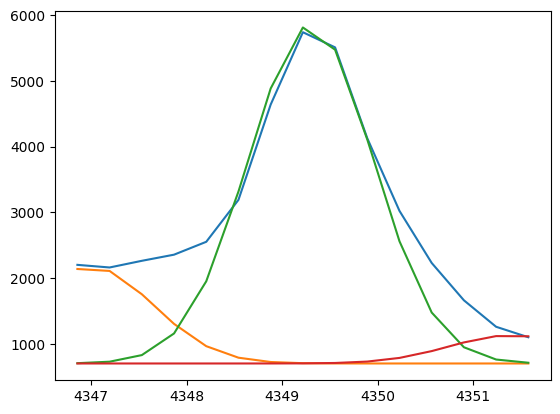

In [98]:
plt.plot(x_arc_hd, y_arc_hd)
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, 2400,   4347, 0, 0.65))
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, 8400, 4349.3, 0, 0.65))
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd,  700, 4351.4, 0, 0.65))

In [99]:
params_arc_hd = Parameters()
params_arc_hd.add('z', value=0.0, vary=False)
params_arc_hd.add('mu1', value=  4347, vary=False)
params_arc_hd.add('mu2', value=4349.3, vary=False)
params_arc_hd.add('mu3', value=4351.4, vary=False)
params_arc_hd.add('arc1', value=2400, min=0.)
params_arc_hd.add('arc2', value=8400, min=0.)
params_arc_hd.add('arc3', value= 700, min=0.)
params_arc_hd.add('sigma', value=0.65, min=0.)
params_arc_hd.add('bkg', value=700, vary=False)

def residual_arc_hd(params_arc_hd, x, data, uncertainty):
    
    z = params_arc_hd['z']
    mu1 = params_arc_hd['mu1']
    mu2 = params_arc_hd['mu2']
    mu3 = params_arc_hd['mu3']
    flux1 = params_arc_hd['arc1']
    flux2 = params_arc_hd['arc2']
    flux3 = params_arc_hd['arc3']
    sigma = params_arc_hd['sigma']
    bkg = params_arc_hd['bkg']
    
    x = x_arc_hd
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hd) / 10

np.random.seed(136)
out_arc_hd = minimize(residual_arc_hd, params_arc_hd, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:17<00:00, 32.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 77.31296496  33.8895645  105.46444033  51.53724535]


In [100]:
out_arc_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4347.00000,,,4347,-inf,inf,False
mu2,4349.30000,,,4349.3,-inf,inf,False
mu3,4351.40000,,,4351.4,-inf,inf,False
arc1,2817.28755,10.8719217,(0.39%),2400,0.00000000,inf,True
arc2,8746.54028,11.0861332,(0.13%),8400,0.00000000,inf,True
arc3,970.445029,10.9733595,(1.13%),700,0.00000000,inf,True
sigma,0.71700010,0.00105696,(0.15%),0.65,0.00000000,inf,True
bkg,700.000000,,,700,-inf,inf,False


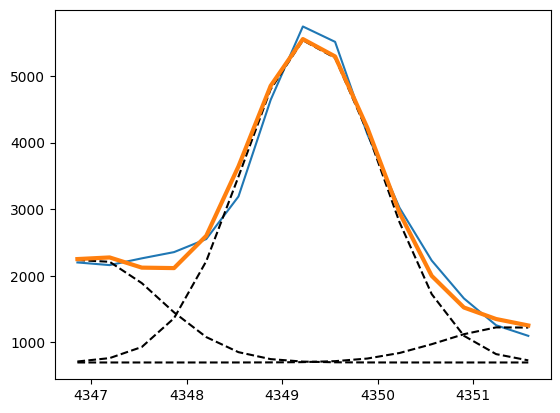

In [101]:
arc1_hd = out_arc_hd.flatchain.arc1.mean()
arc2_hd = out_arc_hd.flatchain.arc2.mean()
arc3_hd = out_arc_hd.flatchain.arc3.mean()
sigma_arc_hd = out_arc_hd.flatchain.sigma.mean()

plt.plot(x_arc_hd, y_arc_hd)
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, arc1_hd,   4347, 0, sigma_arc_hd), color='black', ls='--')
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, arc2_hd, 4349.3, 0, sigma_arc_hd), color='black', ls='--')
plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, arc3_hd, 4351.4, 0, sigma_arc_hd), color='black', ls='--')

plt.plot(x_arc_hd, 700 + gaussian(x_arc_hd, arc1_hd,   4347, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc2_hd, 4349.3, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc3_hd, 4351.4, 0, sigma_arc_hd), lw=3
)

# [OII]3726 + [OII]3729

### Arc lines

In [110]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3729 = [wave_cat['[OII]3729']*(1 + z_BN[igal]) - 2, wave_cat['[OII]3729']*(1 + z_BN[igal]) + 10]
mask_arc_3729 = (wcal_blue[4].data['wave_soln'][0] >= wlims_3729[0]) & (wcal_blue[4].data['wave_soln'][0] < wlims_3729[1])

# Arc spectra around the fitted line
x_arc_3729 = wcal_blue[4].data['wave_soln'][0][mask_arc_3729]
y_arc_3729 = wcal_blue[25].data[:, 1][mask_arc_3729]

100%|███████████████████████████████████████| 2500/2500 [02:06<00:00, 19.74it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 53.38002956  73.79678139 120.1239268   76.73052146  65.59735929
  89.38888246  50.46991528  66.87677792]


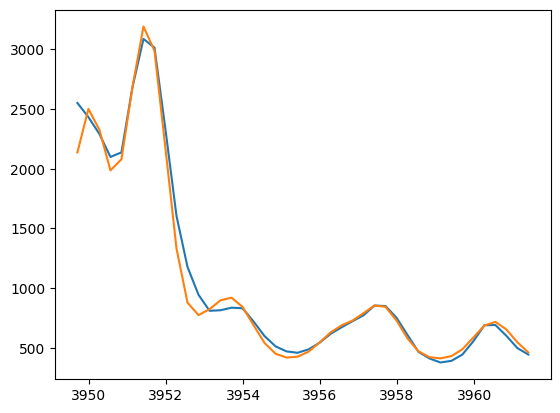

In [111]:
plt.plot(x_arc_3729, y_arc_3729)
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, 2600, 3950, 0, 0.5) \
                         + gaussian(x_arc_3729, 3500, 3951.5, 0, 0.5) \
                         + gaussian(x_arc_3729,  300, 3953, 0, 0.5) \
                         + gaussian(x_arc_3729,  550, 3953.8, 0, 0.5) \
                         + gaussian(x_arc_3729,  300, 3956.5, 0, 0.5) \
                         + gaussian(x_arc_3729,  550, 3957.6, 0, 0.5) \
                         + gaussian(x_arc_3729,  400, 3960.5, 0, 0.5)
)

params_arc_3729 = Parameters()
params_arc_3729.add('z', value=0.0, vary=False)
params_arc_3729.add('mu1', value=3950, vary=False)
params_arc_3729.add('mu2', value=3951.5, vary=False)
params_arc_3729.add('mu3', value=3953, vary=False)
params_arc_3729.add('mu4', value=3953.8, vary=False)
params_arc_3729.add('mu5', value=3956.5, vary=False)
params_arc_3729.add('mu6', value=3957.6, vary=False)
params_arc_3729.add('mu7', value=3960.5, vary=False)
params_arc_3729.add('arc1', value=2600, min=0.)
params_arc_3729.add('arc2', value=3500, min=0.)
params_arc_3729.add('arc3', value=300, min=0.)
params_arc_3729.add('arc4', value=550, min=0.)
params_arc_3729.add('arc5', value=300, min=0.)
params_arc_3729.add('arc6', value=550, min=0.)
params_arc_3729.add('arc7', value=400, min=0.)
params_arc_3729.add('sigma', value=0.5, min=0.)
params_arc_3729.add('bkg', value=400, vary=False)

def residual_arc_3729(params_arc_3729, x, data, uncertainty):
    
    z = params_arc_3729['z']
    mu1 = params_arc_3729['mu1']
    mu2 = params_arc_3729['mu2']
    mu3 = params_arc_3729['mu3']
    mu4 = params_arc_3729['mu4']
    mu5 = params_arc_3729['mu5']
    mu6 = params_arc_3729['mu6']
    mu7 = params_arc_3729['mu7']
    flux1 = params_arc_3729['arc1']
    flux2 = params_arc_3729['arc2']
    flux3 = params_arc_3729['arc3']
    flux4 = params_arc_3729['arc4']
    flux5 = params_arc_3729['arc5']
    flux6 = params_arc_3729['arc6']
    flux7 = params_arc_3729['arc7']
    sigma = params_arc_3729['sigma']
    bkg = params_arc_3729['bkg']
    
    x = x_arc_3729
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    
    return (model - y_arc_3729) / 10

np.random.seed(136)
out_arc_3729 = minimize(residual_arc_3729, params_arc_3729, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

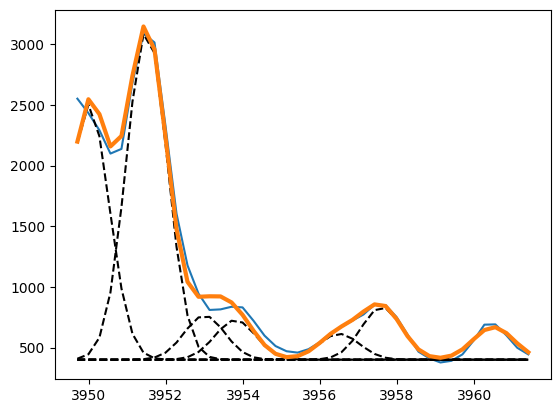

In [112]:
arc1_3729 = out_arc_3729.flatchain.arc1.mean()
arc2_3729 = out_arc_3729.flatchain.arc2.mean()
arc3_3729 = out_arc_3729.flatchain.arc3.mean()
arc4_3729 = out_arc_3729.flatchain.arc4.mean()
arc5_3729 = out_arc_3729.flatchain.arc5.mean()
arc6_3729 = out_arc_3729.flatchain.arc6.mean()
arc7_3729 = out_arc_3729.flatchain.arc7.mean()
sigma_arc_3729 = out_arc_3729.flatchain.sigma.mean()

plt.plot(x_arc_3729, y_arc_3729)

plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc1_3729, 3950, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc2_3729, 3951.5, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc3_3729, 3953, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc4_3729, 3953.8, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc5_3729, 3956.5, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc6_3729, 3957.6, 0, sigma_arc_3729), color='black', ls='--')
plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc7_3729, 3960.5, 0, sigma_arc_3729), color='black', ls='--')

plt.plot(x_arc_3729, 400 + gaussian(x_arc_3729, arc1_3729, 3950, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc2_3729, 3951.5, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc3_3729, 3953, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc4_3729, 3953.8, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc5_3729, 3956.5, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc6_3729, 3957.6, 0, sigma_arc_3729) \
        + gaussian(x_arc_3729, arc7_3729, 3960.5, 0, sigma_arc_3729), lw=3
)

----

# High ionization

# [SIII]9532

### Arc lines

In [121]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9532 = [wave_cat['[SIII]9532']*(1 + z_BN[igal]) - 90, wave_cat['[SIII]9532']*(1 + z_BN[igal]) ]
mask_arc_9532 = (wcal_red[16].data['wave_soln'][0] >= wlims_9532[0]) & (wcal_red[16].data['wave_soln'][0] < wlims_9532[1])

# Arc spectra around the fitted line
x_arc_9532 = wcal_red[16].data['wave_soln'][0][mask_arc_9532]
y_arc_9532 = wcal_red[19].data[:, 7][mask_arc_9532]

100%|███████████████████████████████████████| 2500/2500 [00:47<00:00, 52.11it/s]


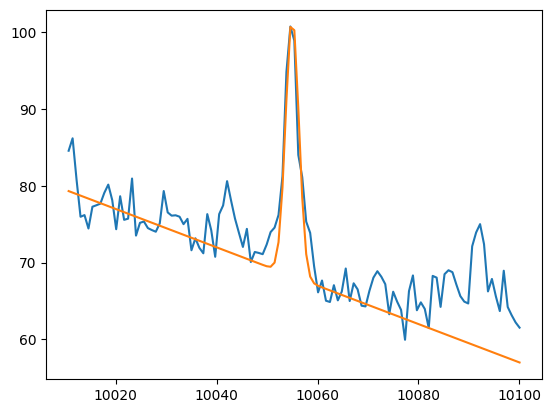

In [122]:
plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, 2582 - (0.25 * x_arc_9532) + gaussian(x_arc_9532, 110, 10055, 0, 1.3))

params_arc_9532 = Parameters()
params_arc_9532.add('z', value=0.0, vary=False)
params_arc_9532.add('mu', value=10055, vary=False)
params_arc_9532.add('arc', value=110, min=0.)
params_arc_9532.add('sigma', value=1.3, min=0.)
params_arc_9532.add('bkg_m', value=-0.25, vary=True)
params_arc_9532.add('bkg_n', value=2582, vary=True)

def residual_arc_9532(params_arc_9532, x, data, uncertainty):
    
    z = params_arc_9532['z']
    mu = params_arc_9532['mu']
    flux = params_arc_9532['arc']
    sigma = params_arc_9532['sigma']
    m = params_arc_9532['bkg_m']
    n = params_arc_9532['bkg_n']
    
    x = x_arc_9532
    bkg = (m * x) + n
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9532) / 10

np.random.seed(136)
out_arc_9532 = minimize(residual_arc_9532, params_arc_9532, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

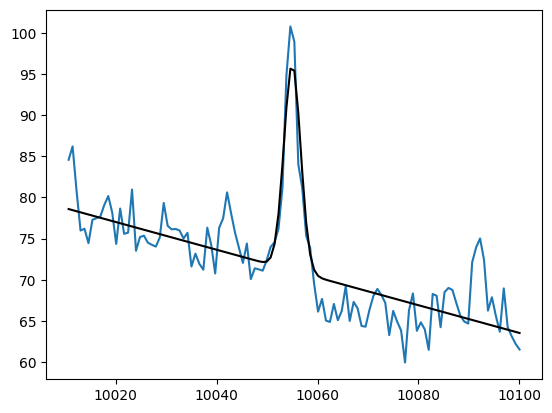

In [123]:
arc_9532 = out_arc_9532.flatchain.arc.mean()
sigma_arc_9532 = out_arc_9532.flatchain.sigma.mean()
bkg_m_9532 = out_arc_9532.flatchain.bkg_m.mean()
bkg_n_9532 = out_arc_9532.flatchain.bkg_n.mean()

plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, bkg_n_9532 + (bkg_m_9532 * x_arc_9532) + gaussian(x_arc_9532, arc_9532, 10055, 0, sigma_arc_9532), color='black')

# [SIII]9069

### Arc lines

In [132]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9069 = [wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 30, wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 70]
mask_arc_9069 = (wcal_red[16].data['wave_soln'][0] >= wlims_9069[0]) & (wcal_red[16].data['wave_soln'][0] < wlims_9069[1])

# Arc spectra around the fitted line
x_arc_9069 = wcal_red[16].data['wave_soln'][0][mask_arc_9069]
y_arc_9069 = wcal_red[19].data[:, 7][mask_arc_9069]

100%|███████████████████████████████████████| 2500/2500 [00:44<00:00, 56.10it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 18.38229211  19.54964853 111.38570569]


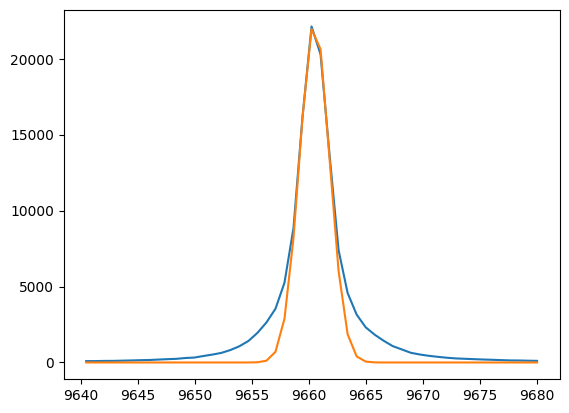

In [133]:
plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, gaussian(x_arc_9069, 73000, 9660.5, 0, 1.3))

params_arc_9069 = Parameters()
params_arc_9069.add('z', value=0.0, vary=False)
params_arc_9069.add('mu', value=9660.5, vary=False)
params_arc_9069.add('arc', value=73000, min=0.)
params_arc_9069.add('sigma', value=1.3, min=0.)
params_arc_9069.add('bkg', value=100, vary=True)

def residual_arc_9069(params_arc_9069, x, data, uncertainty):
    
    z = params_arc_9069['z']
    mu = params_arc_9069['mu']
    flux = params_arc_9069['arc']
    sigma = params_arc_9069['sigma']
    bkg = params_arc_9069['bkg']
    
    x = x_arc_9069
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9069) / 10

np.random.seed(136)
out_arc_9069 = minimize(residual_arc_9069, params_arc_9069, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

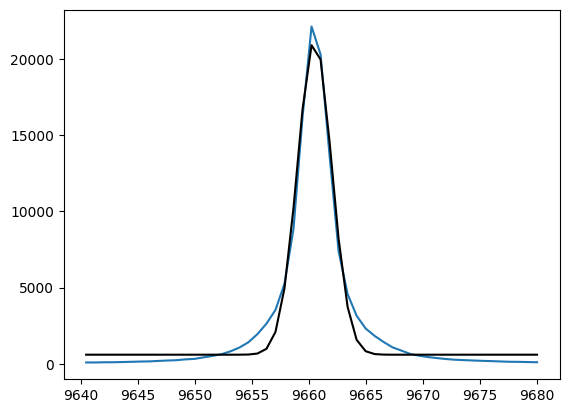

In [134]:
arc_9069 = out_arc_9069.flatchain.arc.mean()
sigma_arc_9069 = out_arc_9069.flatchain.sigma.mean()
bkg_arc_9069 = out_arc_9069.flatchain.bkg.mean()

plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, bkg_arc_9069 + gaussian(x_arc_9069, arc_9069, 9660.5, 0, sigma_arc_9069), color='black')

# [OI]6300 + [SIII]6312

### Arc lines

In [143]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6312 = [wave_cat['[SIII]6312']*(1 + z_BN[igal]) - 15, wave_cat['[SIII]6312']*(1 + z_BN[igal]) + 5]
mask_arc_6312 = (wcal_red[10].data['wave_soln'][0] >= wlims_6312[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_6312[1])

# Arc spectra around the fitted line
x_arc_6312 = wcal_red[10].data['wave_soln'][0][mask_arc_6312]
y_arc_6312 = wcal_red[19].data[:, 4][mask_arc_6312]

100%|███████████████████████████████████████| 2500/2500 [01:22<00:00, 30.26it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [103.15588865  77.46203493  94.57943467  87.54439391  83.1357007
  77.8884208 ]


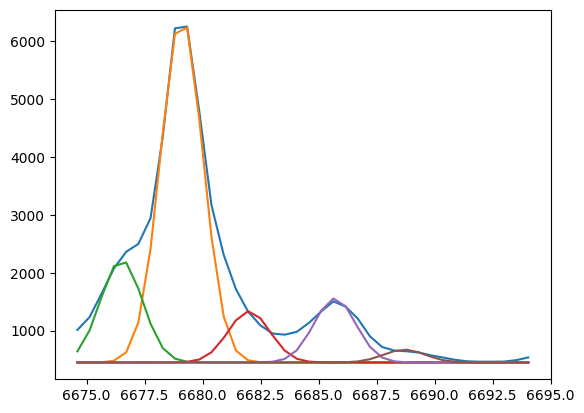

In [144]:
plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, 13500, 6679.1, 0, 0.9))
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, 4000, 6676.5, 0, 0.9))
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, 2000, 6682, 0, 0.9))
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, 2500, 6685.7, 0, 0.9))
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, 500, 6688.7, 0, 0.9))

params_arc_6312 = Parameters()
params_arc_6312.add('z', value=0.0, vary=False)
params_arc_6312.add('mu1', value=6679.1, vary=False)
params_arc_6312.add('mu2', value=6676.5, vary=False)
params_arc_6312.add('mu3', value=6682, vary=False)
params_arc_6312.add('mu4', value=6685.7, vary=False)
params_arc_6312.add('mu5', value=6688.7, vary=False)
params_arc_6312.add('arc1', value=13500, min=0.)
params_arc_6312.add('arc2', value=4000, min=0.)
params_arc_6312.add('arc3', value=2000, min=0.)
params_arc_6312.add('arc4', value=2500, min=0.)
params_arc_6312.add('arc5', value=500, min=0.)
params_arc_6312.add('sigma', value=0.9, min=0.)
params_arc_6312.add('bkg', value=450, vary=False)

def residual_arc_6312(params_arc_6312, x, data, uncertainty):
    
    z = params_arc_6312['z']
    mu1 = params_arc_6312['mu1']
    mu2 = params_arc_6312['mu2']
    mu3 = params_arc_6312['mu3']
    mu4 = params_arc_6312['mu4']
    mu5 = params_arc_6312['mu5']
    flux1 = params_arc_6312['arc1']
    flux2 = params_arc_6312['arc2']
    flux3 = params_arc_6312['arc3']
    flux4 = params_arc_6312['arc4']
    flux5 = params_arc_6312['arc5']
    sigma = params_arc_6312['sigma']
    bkg = params_arc_6312['bkg']
    
    x = x_arc_6312
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_6312) / 10

np.random.seed(136)
out_arc_6312 = minimize(residual_arc_6312, params_arc_6312, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

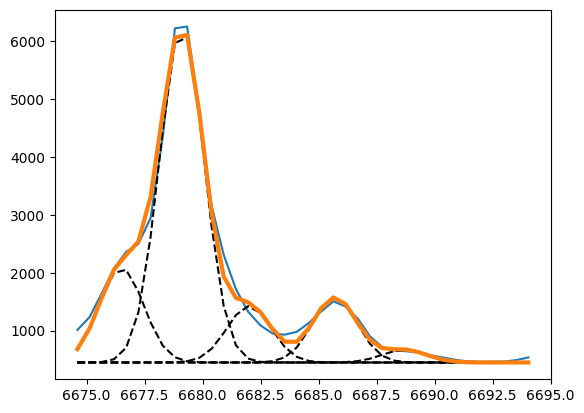

In [145]:
arc1_6312 = out_arc_6312.flatchain.arc1.mean()
arc2_6312 = out_arc_6312.flatchain.arc2.mean()
arc3_6312 = out_arc_6312.flatchain.arc3.mean()
arc4_6312 = out_arc_6312.flatchain.arc4.mean()
arc5_6312 = out_arc_6312.flatchain.arc5.mean()
sigma_arc_6312 = out_arc_6312.flatchain.sigma.mean()

plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc1_6312, 6679.1, 0, sigma_arc_6312), color='black', ls='--')
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc2_6312, 6676.5, 0, sigma_arc_6312), color='black', ls='--')
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc3_6312, 6682, 0, sigma_arc_6312), color='black', ls='--')
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc4_6312, 6685.7, 0, sigma_arc_6312), color='black', ls='--')
plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc5_6312, 6688.7, 0, sigma_arc_6312), color='black', ls='--')

plt.plot(x_arc_6312, 450 + gaussian(x_arc_6312, arc1_6312, 6679.1, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc2_6312, 6676.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc3_6312, 6682, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc4_6312, 6685.7, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc5_6312, 6688.7, 0, sigma_arc_6312), lw=3
)

# [OIII]5007 + HeI 5015

### Arc lines

In [154]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5007 = [wave_cat['[OIII]5007']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]5007']*(1 + z_BN[igal]) + 10]
mask_arc_5007 = (wcal_red[4].data['wave_soln'][0] >= wlims_5007[0]) & (wcal_red[4].data['wave_soln'][0] < wlims_5007[1])

# Arc spectra around the fitted line
x_arc_5007 = wcal_red[4].data['wave_soln'][0][mask_arc_5007]
y_arc_5007 = wcal_red[19].data[:, 1][mask_arc_5007]

100%|███████████████████████████████████████| 2500/2500 [01:18<00:00, 31.77it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [86.37059196 59.48814932 76.87122555 65.15474377 57.58585814 59.29049478
 80.59889624 73.63211108]


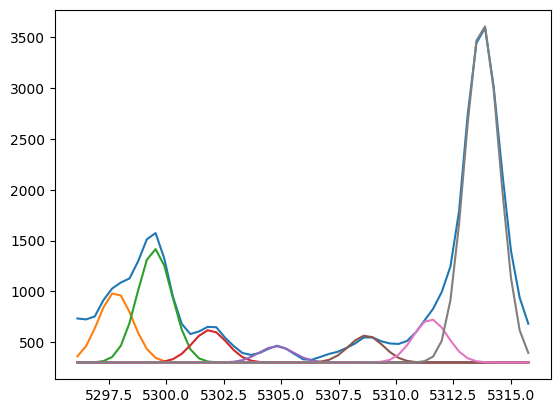

In [155]:
plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 1300, 5297.8, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 2100, 5299.5, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 600, 5301.9, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 300, 5304.8, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 500, 5308.7, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 800, 5311.5, 0, 0.75))
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, 6300, 5313.75, 0, 0.75))

params_arc_5007 = Parameters()
params_arc_5007.add('z', value=0.0, vary=False)
params_arc_5007.add('mu1', value=5297.8, vary=False)
params_arc_5007.add('mu2', value=5299.5, vary=False)
params_arc_5007.add('mu3', value=5301.9, vary=False)
params_arc_5007.add('mu4', value=5304.8, vary=False)
params_arc_5007.add('mu5', value=5308.7, vary=False)
params_arc_5007.add('mu6', value=5311.5, vary=False)
params_arc_5007.add('mu7', value=5313.75, vary=False)
params_arc_5007.add('arc1', value=1300, min=0.)
params_arc_5007.add('arc2', value=2100, min=0.)
params_arc_5007.add('arc3', value=600, min=0.)
params_arc_5007.add('arc4', value=300, min=0.)
params_arc_5007.add('arc5', value=500, min=0.)
params_arc_5007.add('arc6', value=800, min=0.)
params_arc_5007.add('arc7', value=6300, min=0.)
params_arc_5007.add('sigma', value=0.75, min=0.)
params_arc_5007.add('bkg', value=300, vary=False)

def residual_arc_5007(params_arc_5007, x, data, uncertainty):
    
    z = params_arc_5007['z']
    mu1 = params_arc_5007['mu1']
    mu2 = params_arc_5007['mu2']
    mu3 = params_arc_5007['mu3']
    mu4 = params_arc_5007['mu4']
    mu5 = params_arc_5007['mu5']
    mu6 = params_arc_5007['mu6']
    mu7 = params_arc_5007['mu7']
    flux1 = params_arc_5007['arc1']
    flux2 = params_arc_5007['arc2']
    flux3 = params_arc_5007['arc3']
    flux4 = params_arc_5007['arc4']
    flux5 = params_arc_5007['arc5']
    flux6 = params_arc_5007['arc6']
    flux7 = params_arc_5007['arc7']
    sigma = params_arc_5007['sigma']
    bkg = params_arc_5007['bkg']
    
    x = x_arc_5007
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    return (model - y_arc_5007) / 10

np.random.seed(136)
out_arc_5007 = minimize(residual_arc_5007, params_arc_5007, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

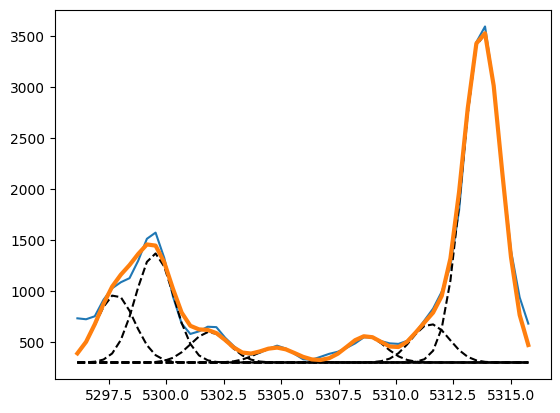

In [156]:
arc1_5007 = out_arc_5007.flatchain.arc1.mean()
arc2_5007 = out_arc_5007.flatchain.arc2.mean()
arc3_5007 = out_arc_5007.flatchain.arc3.mean()
arc4_5007 = out_arc_5007.flatchain.arc4.mean()
arc5_5007 = out_arc_5007.flatchain.arc5.mean()
arc6_5007 = out_arc_5007.flatchain.arc6.mean()
arc7_5007 = out_arc_5007.flatchain.arc7.mean()
sigma_arc_5007 = out_arc_5007.flatchain.sigma.mean()

plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc1_5007, 5297.8, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc2_5007, 5299.5, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc3_5007, 5301.9, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc4_5007, 5304.8, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc5_5007, 5308.7, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc6_5007, 5311.5, 0, sigma_arc_5007), color='black', ls='--')
plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc7_5007, 5313.75, 0, sigma_arc_5007), color='black', ls='--')

plt.plot(x_arc_5007, 300 + gaussian(x_arc_5007, arc1_5007, 5297.8, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc2_5007, 5299.5, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc3_5007, 5301.9, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc4_5007, 5304.8, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc5_5007, 5308.7, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc6_5007, 5311.5, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc7_5007, 5313.75, 0, sigma_arc_5007), lw=3
)

# [OIII]4363

### Arc lines

In [165]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4363 = [wave_cat['[OIII]4363']*(1 + z_BN[igal]) , wave_cat['[OIII]4363']*(1 + z_BN[igal]) + 10]
mask_arc_4363 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4363[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4363[1])

# Arc spectra around the fitted line
x_arc_4363 = wcal_blue[10].data['wave_soln'][0][mask_arc_4363]
y_arc_4363 = wcal_blue[25].data[:, 4][mask_arc_4363]

100%|███████████████████████████████████████| 2500/2500 [00:54<00:00, 45.71it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [62.78361584 60.90289532 62.01736755 67.11093665 65.18985315 65.10853317
 68.55676399]


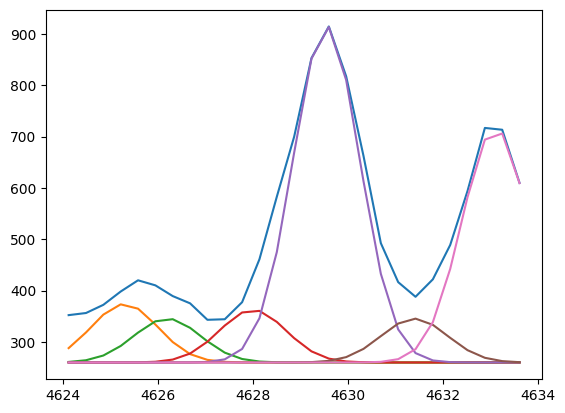

In [166]:
plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 200, 4625.3, 0, 0.7))
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 150, 4626.2, 0, 0.7))
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 180, 4628, 0, 0.7))
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 1150, 4629.55, 0, 0.7))
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 150, 4631.4, 0, 0.7))
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, 800, 4633.1, 0, 0.7))

params_arc_4363 = Parameters()
params_arc_4363.add('z', value=0.0, vary=False)
params_arc_4363.add('mu1', value=4625.3, vary=False)
params_arc_4363.add('mu2', value=4626.2, vary=False)
params_arc_4363.add('mu3', value=4628, vary=False)
params_arc_4363.add('mu4', value=4629.55, vary=False)
params_arc_4363.add('mu5', value=4631.4, vary=False)
params_arc_4363.add('mu6', value=4633.1, vary=False)
params_arc_4363.add('arc1', value=200, min=0.)
params_arc_4363.add('arc2', value=150, min=0.)
params_arc_4363.add('arc3', value=180, min=0.)
params_arc_4363.add('arc4', value=1150, min=0.)
params_arc_4363.add('arc5', value=150, min=0.)
params_arc_4363.add('arc6', value=800, min=0.)
params_arc_4363.add('sigma', value=0.7, min=0.)
params_arc_4363.add('bkg', value=260, vary=False)

def residual_arc_4363(params_arc_4363, x, data, uncertainty):
    
    z = params_arc_4363['z']
    mu1 = params_arc_4363['mu1']
    mu2 = params_arc_4363['mu2']
    mu3 = params_arc_4363['mu3']
    mu4 = params_arc_4363['mu4']
    mu5 = params_arc_4363['mu5']
    mu6 = params_arc_4363['mu6']
    flux1 = params_arc_4363['arc1']
    flux2 = params_arc_4363['arc2']
    flux3 = params_arc_4363['arc3']
    flux4 = params_arc_4363['arc4']
    flux5 = params_arc_4363['arc5']
    flux6 = params_arc_4363['arc6']
    sigma = params_arc_4363['sigma']
    bkg = params_arc_4363['bkg']
    
    x = x_arc_4363
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6
    return (model - y_arc_4363) / 10

np.random.seed(136)
out_arc_4363 = minimize(residual_arc_4363, params_arc_4363, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

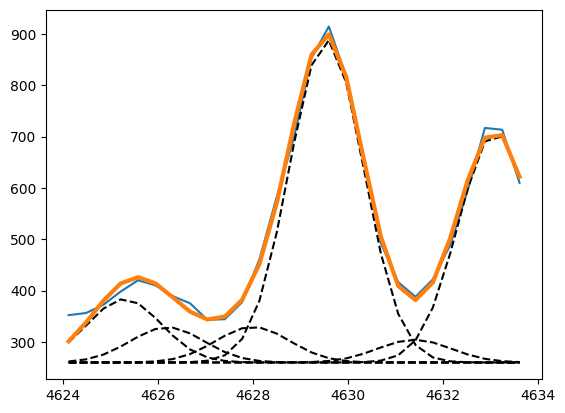

In [167]:
arc1_4363 = out_arc_4363.flatchain.arc1.mean()
arc2_4363 = out_arc_4363.flatchain.arc2.mean()
arc3_4363 = out_arc_4363.flatchain.arc3.mean()
arc4_4363 = out_arc_4363.flatchain.arc4.mean()
arc5_4363 = out_arc_4363.flatchain.arc5.mean()
arc6_4363 = out_arc_4363.flatchain.arc6.mean()
sigma_arc_4363 = out_arc_4363.flatchain.sigma.mean()

plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc1_4363, 4625.3, 0, sigma_arc_4363), color='black', ls='--')
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc2_4363, 4626.2, 0, sigma_arc_4363), color='black', ls='--')
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc3_4363, 4628, 0, sigma_arc_4363), color='black', ls='--')
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc4_4363, 4629.55, 0, sigma_arc_4363), color='black', ls='--')
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc5_4363, 4631.4, 0, sigma_arc_4363), color='black', ls='--')
plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc6_4363, 4633.1, 0, sigma_arc_4363), color='black', ls='--')

plt.plot(x_arc_4363, 260 + gaussian(x_arc_4363, arc1_4363, 4625.3, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc2_4363, 4626.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc3_4363, 4628, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc4_4363, 4629.55, 0, sigma_arc_4363)\
         + gaussian(x_arc_4363, arc5_4363, 4631.4, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc6_4363, 4633.1, 0, sigma_arc_4363), lw=3
)

# Saving Arc data

In [176]:
sigma_arc = np.array([sigma_arc_3729, # 16 blue
                      sigma_arc_hd,
                      sigma_arc_hg,
                      sigma_arc_4363, # 13 blue
                      sigma_arc_hb, # 12
                      sigma_arc_4959, # 12
                      sigma_arc_5007, # 12
                      sigma_arc_6312, # 9
                      sigma_arc_ha, # 9
                      sigma_arc_6730, # 9
                      sigma_arc_7330, # 8
                      sigma_arc_9069, # 6
                      sigma_arc_9532]) # 6

x_arc = np.array([np.median(x_arc_3729),
                  np.median(x_arc_hd),
                  np.median(x_arc_hg),
                  np.median(x_arc_4363),
                  np.median(x_arc_hb),
                  np.median(x_arc_4959),
                  np.median(x_arc_5007),
                  np.median(x_arc_6312),
                  np.median(x_arc_ha),
                  np.median(x_arc_6730),
                  np.median(x_arc_7330),
                  np.median(x_arc_9069),
                  np.median(x_arc_9532)])

In [177]:
params_sigma_arc = Parameters()
params_sigma_arc.add('m', value=(sigma_arc[-1] - sigma_arc[0])/(x_arc[-1] - x_arc[0]))
params_sigma_arc.add('n', value=-0.2)

def residual_sigma_arc(params_sigma_arc, x, data, uncertainty):
    
    m = params_sigma_arc['m']
    n = params_sigma_arc['n']
    
    x = x_arc
    model = (m * x_arc) + n
    return (model - sigma_arc) / 0.05

np.random.seed(136)
out_sigma_arc = minimize(residual_sigma_arc, params_sigma_arc, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:15<00:00, 161.00it/s]


In [178]:
lmfit.report_fit(out_sigma_arc.params)

[[Variables]]
    m:  1.6064e-04 +/- 7.3217e-06 (4.56%) (init = 0.000184433)
    n: -0.04641747 +/- 0.04768681 (102.73%) (init = -0.2)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, n) = -0.9573


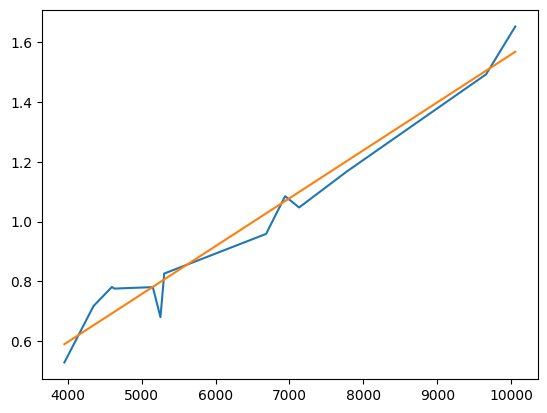

In [179]:
m = out_sigma_arc.flatchain.m.mean()
n = out_sigma_arc.flatchain.n.mean()

plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (m * x_arc) + n)

In [180]:
sigma_arc_16 = np.array([sigma_arc_3729])
sigma_arc_13 = np.array([sigma_arc_4363])
sigma_arc_12 = np.array([sigma_arc_hb, sigma_arc_4959, sigma_arc_5007])
sigma_arc_9 = np.array([sigma_arc_6312, sigma_arc_ha, sigma_arc_6730])
sigma_arc_8 = np.array([sigma_arc_7330])
sigma_arc_6 = np.array([sigma_arc_9069, sigma_arc_9532])

x_arc_16 = np.array([np.median(x_arc_3729)])
x_arc_13 = np.array([np.median(x_arc_4363)])
x_arc_12 = np.array([np.median(x_arc_hb), np.median(x_arc_4959), np.median(x_arc_5007)])
x_arc_9 = np.array([np.median(x_arc_6312), np.median(x_arc_ha), np.median(x_arc_6730)])
x_arc_8 = np.array([np.median(x_arc_7330)])
x_arc_6 = np.array([np.median(x_arc_9069), np.median(x_arc_9532)])

x_sky_9 = np.array([6570.388  , 6899.96714, 7299.48912])
sigma_sky_9 = np.array([0.95383926, 0.93387183, 1.14680285])

Text(0.5, 0, 'Wavelength (\\AA)')

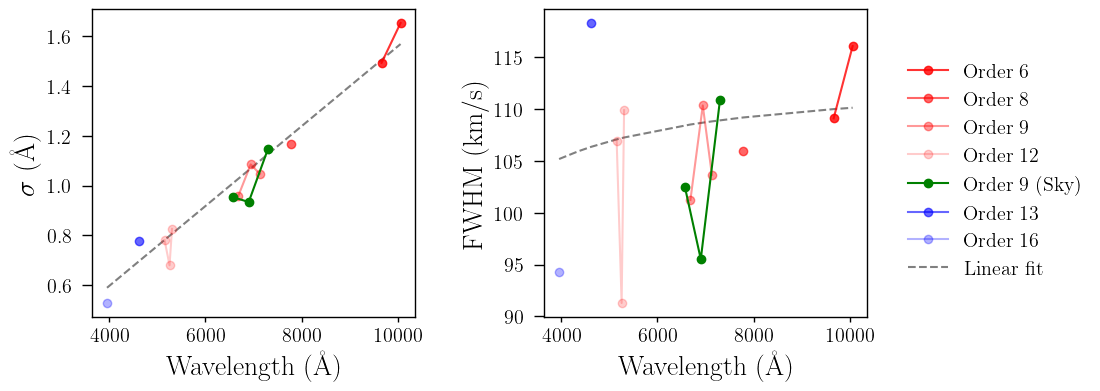

In [181]:
texPlot('on')

fig, axs = plt.subplots(1, 2)
fig.set_size_inches((10, 4))
fig.subplots_adjust(wspace=0.4)

axs[0].plot(x_arc_6, sigma_arc_6, marker='o', label='Order 6', color='red', alpha=0.8)
axs[0].plot(x_arc_8, sigma_arc_8, marker='o', label='Order 8', color='red', alpha=0.6)
axs[0].plot(x_arc_9, sigma_arc_9, marker='o', label='Order 9', color='red', alpha=0.4)
axs[0].plot(x_arc_12, sigma_arc_12, marker='o', label='Order 12', color='red', alpha=0.2)
axs[0].plot(x_sky_9, sigma_sky_9, marker='o', label='Order 9 (Sky)', color='green')
axs[0].plot(x_arc_13, sigma_arc_13, marker='o', label='Order 13', color='blue', alpha=0.6)
axs[0].plot(x_arc_16, sigma_arc_16, marker='o', label='Order 16', color='blue', alpha=0.3)


axs[0].plot(x_arc, (m * x_arc) + n, ls='--', color='gray', label='Linear fit', zorder=0)

axs[0].set_ylabel('$\sigma$ (\AA)')
axs[0].set_xlabel('Wavelength (\AA)')
axs[0].legend(loc=(2.5, 0.1))

axs[1].plot(x_arc_6, FWHM(sigma_arc_6, x_arc_6), marker='o', label='Order 6', color='red', alpha=0.8)
axs[1].plot(x_arc_8, FWHM(sigma_arc_8, x_arc_8), marker='o', label='Order 8', color='red', alpha=0.6)
axs[1].plot(x_arc_9, FWHM(sigma_arc_9, x_arc_9), marker='o', label='Order 9', color='red', alpha=0.4)
axs[1].plot(x_arc_12, FWHM(sigma_arc_12, x_arc_12), marker='o', label='Order 12', color='red', alpha=0.2)
axs[1].plot(x_sky_9, FWHM(sigma_sky_9, x_sky_9), marker='o', label='Order 9 (skylines)', color='green')
axs[1].plot(x_arc_13, FWHM(sigma_arc_13, x_arc_13), marker='o', label='Order 13', color='blue', alpha=0.6)
axs[1].plot(x_arc_16, FWHM(sigma_arc_16, x_arc_16), marker='o', label='Order 16', color='blue', alpha=0.3)


axs[1].plot(x_arc, FWHM((m * x_arc) + n, x_arc), ls='--', color='gray', label='Linear fit', zorder=0)

axs[1].set_ylabel('FWHM (km/s)')
axs[1].set_xlabel('Wavelength (\AA)')

#fig.savefig('/home/benjamin/Documents/analogs/arc_sky.jpg', bbox_inches='tight', dpi=200);